# Load Model and Data

In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import torch 
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.models.utils import load_tokenizer
from dreamerv4uwm.models.utils import load_denoiser
# DATA_PATH = "/home/mim-server/datasets/soar_data_sharded"
# DATA_PATH = "/home/mim-server/datasets/Finger/H5/combined"
DATA_PATH = "/home/mim-server/datasets/pushT/sharded/"
# DATA_PATH = "/home/mim-server/datasets/pushT/sharded-demo/"
# DATA_PATH = "/home/mim-server/datasets/pushT/synthetic-reward/"
# DATA_PATH = "/media/mim-server/Volume1/lewm/sharded/cube/"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resolution = (256, 256)

In [19]:
from hydra import initialize, compose
from omegaconf import OmegaConf
with initialize(version_base=None, config_path="../scripts/config"):
    cfg = compose(config_name="dynamics/pushT.yaml")
    # cfg = compose(config_name="dynamics/lewm-cubes.yaml")

/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [20]:
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/no-shortcuts/all-2x-temporal-485204.pt"
dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/align/mix-pushT-v0-longrun/12000.pt"
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/lewm-cubes/joint/250000.pt"

In [21]:
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"
cfg.dynamics_ckpt = dynamics_ckpt
cfg.tokenizer_ckpt=tokenizer_ckpt
denoiser = load_denoiser(cfg, device, max_num_forward_steps=300)
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300)
tokenizer = tokenizer.eval().cuda()
denoiser = denoiser.eval().cuda()

In [22]:
import mediapy
from torch.nn.functional import interpolate

dataset = ShardedHDF5Dataset(
        data_dir=DATA_PATH,
        window_size=96,
        stride=1,
        split='test',
        train_fraction=0.9,
        split_seed=123,
    )

# Arbitrary index into that episode
batch = dataset[torch.randint(len(dataset), (1,)).item()]
# imgs = batch["image"][:,[2, 1, 0], :, :]  # (T, C, H, W)
imgs = batch["image"]  # (T, C, H, W)
actions = batch["action"][:,:cfg.denoiser.n_actions]  # (1, T, N_lat, D_lat)
# actions=torch.zeros_like(actions)
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])

Test split: 12121 windows from 2 episodes


This browser does not support the video tag.


This browser does not support the video tag.


In [23]:
from dreamerv4uwm.sampling import unified_flowmatching_sampler
import matplotlib.pyplot as plt

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.
    
    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    import numpy as np
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()  # (n, H, W, C)
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

def plotActions(actions, figsize=None):
    import numpy as np
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    # if figsize is None:
    figsize = (3 , 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.plot(act[:, 0], linewidth=3, label=r'$\mathbf{v_x}$')
    ax.plot(act[:, 1], linewidth=3, label=r'$\mathbf{v_y}$')
    ax.set_ylim(-1., 1.)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

In [24]:
num_pred_steps = 63
num_diffusion_steps = 16
T_ctx = 1
latents_ctx = latents[:, :T_ctx, ...].clone()


This browser does not support the video tag.


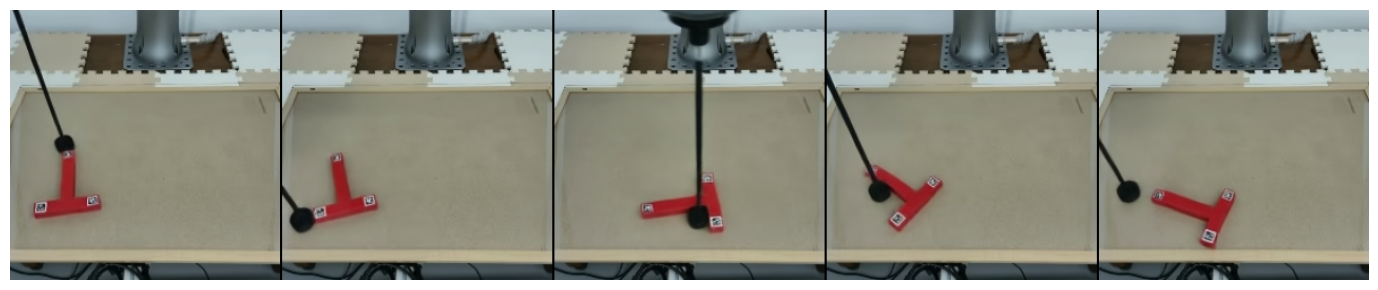

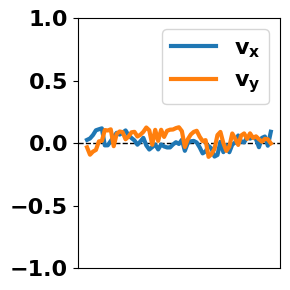

In [25]:
ctx_actions_policy = actions[:T_ctx][None].cuda()  # (1, T_ctx, n_act)
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol, pred_act_pol = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol = tokenizer.decode(pred_obs_pol)

plotVideo(img_pred_pol[0].to(torch.float32))
# plotVideo(imgs[0,0:T_ctx].to(torch.float32))
plotSnapshots(img_pred_pol[0].to(torch.float32))
pr_act = pred_act_pol[0].cpu().float().numpy()
plotActions(pr_act)

In [26]:
import math
import torch
from dreamerv4uwm.sampling import get_noise_index


@torch.no_grad()
def policy_sampler(
    denoiser,
    ctx_latents,            # (B, T_ctx, N_lat, D_lat) — clean context obs
    ctx_actions,            # (B, T_ctx, n_act)        — clean context actions
    num_pred_steps=1,
    num_diffusion_steps=4,  # power of two
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Simplified policy-mode Euler sampler (single call, no shortcut, no cache).

    Context obs and actions are conditioned (slightly noised at tau_cond);
    future obs latents and actions are jointly denoised from pure noise.
    """
    assert (num_diffusion_steps & (num_diffusion_steps - 1)) == 0, \
        "num_diffusion_steps must be a power of two"

    device = ctx_latents.device
    dtype  = ctx_latents.dtype
    B, T_ctx, N_lat, D_lat = ctx_latents.shape
    T_total = T_ctx + num_pred_steps
    n_act = ctx_actions.shape[-1]
    ctx_actions = ctx_actions.to(device=device, dtype=dtype)

    num_noise_levels  = denoiser.cfg.denoiser.num_noise_levels
    step_index_tensor = torch.zeros((B, T_total), dtype=torch.long, device=device)  # flowmatching: finest step
    tau_cond_idx      = get_noise_index(context_cond_tau, num_noise_levels)
    stride            = num_noise_levels // num_diffusion_steps
    step_size         = 1.0 / num_diffusion_steps

    # obs init: future = pure noise, context = slightly noised clean
    z = torch.randn(B, T_total, N_lat, D_lat, device=device, dtype=dtype)
    z[:, :T_ctx] = (1.0 - context_cond_tau) * torch.randn_like(ctx_latents) + context_cond_tau * ctx_latents

    # action init: same scheme
    z_act = action_noise_std * torch.randn(B, T_total, n_act, device=device, dtype=dtype)
    z_act[:, :T_ctx] = (
        (1.0 - context_cond_tau) * action_noise_std * torch.randn_like(ctx_actions)
        + context_cond_tau * ctx_actions
    )

    for k in range(num_diffusion_steps):
        tau_idx = k * stride
        tau     = tau_idx / float(num_noise_levels)

        obs_sigma_idx = torch.full((B, T_total), tau_idx, dtype=torch.long, device=device)
        act_sigma_idx = torch.full((B, T_total), tau_idx, dtype=torch.long, device=device)
        obs_sigma_idx[:, :T_ctx] = tau_cond_idx
        act_sigma_idx[:, :T_ctx] = tau_cond_idx

        z_hat, act_hat, _ = denoiser(
            noisy_act    = z_act,
            noisy_obs    = z,
            obs_sigma_idx= obs_sigma_idx,
            obs_step_idx = step_index_tensor,
            act_sigma_idx= act_sigma_idx,
            act_step_idx = step_index_tensor,
        )
        act_hat = act_hat.squeeze(-2)

        denom = max(1.0 - tau, 1e-5)
        v_obs = (z_hat   - z    ) / denom
        v_act = (act_hat - z_act) / denom
        z    [:, T_ctx:] = z    [:, T_ctx:] + (v_obs * step_size)[:, T_ctx:]
        z_act[:, T_ctx:] = z_act[:, T_ctx:] + (v_act * step_size)[:, T_ctx:]

    return z[:, T_ctx:], z_act[:, T_ctx:]


@torch.no_grad()
def rolling_window_policy_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — initial obs context (e.g. real history)
    init_actions,           # (B, T_init, n_act)        — initial action context
    total_pred_steps,       # total #frames+actions to generate beyond the init context
    chunk_size=4,           # k: #frames generated per sampler call
    max_context=24,         # cap on #frames fed to the model on each call
    num_diffusion_steps=4,
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Roll the policy sampler forward k frames at a time, growing a long
    trajectory while keeping the model's input context truncated.

    Each iteration:
      1. Take the most-recent `max_context` (obs, action) pairs as context.
      2. Sample `min(chunk_size, remaining)` new (obs, action) pairs jointly.
      3. Append them to the rolling window; older frames fall off implicitly
         on the next iteration.

    Returns
    -------
    pred_obs : (B, total_pred_steps, N_lat, D_lat) — only the newly generated frames
    pred_act : (B, total_pred_steps, n_act)
    """
    device = init_latents.device
    dtype  = init_latents.dtype

    obs_window = init_latents.clone()
    act_window = init_actions.clone().to(device=device, dtype=dtype)

    pred_obs_chunks, pred_act_chunks = [], []
    remaining = total_pred_steps
    while remaining > 0:
        k = min(chunk_size, remaining)

        ctx_obs = obs_window[:, -max_context:]
        ctx_act = act_window[:, -max_context:]

        new_obs, new_act = policy_sampler(
            denoiser,
            ctx_latents        = ctx_obs,
            ctx_actions        = ctx_act,
            num_pred_steps     = k,
            num_diffusion_steps= num_diffusion_steps,
            context_cond_tau   = context_cond_tau,
            action_noise_std   = action_noise_std,
        )

        pred_obs_chunks.append(new_obs)
        pred_act_chunks.append(new_act)
        obs_window = torch.cat([obs_window, new_obs], dim=1)
        act_window = torch.cat([act_window, new_act], dim=1)
        remaining -= k

    return torch.cat(pred_obs_chunks, dim=1), torch.cat(pred_act_chunks, dim=1)

This browser does not support the video tag.


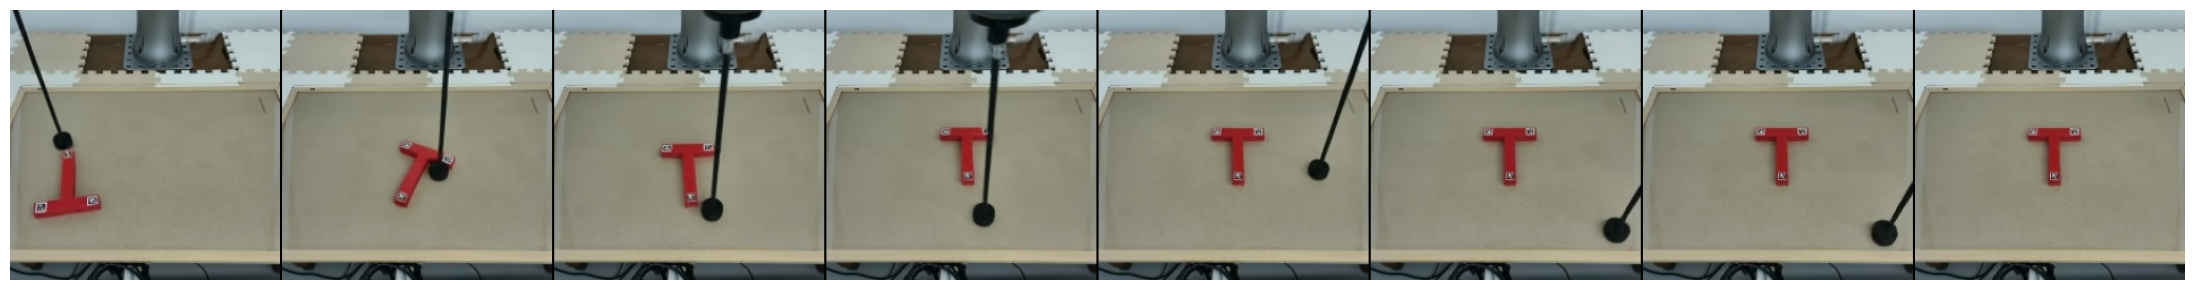

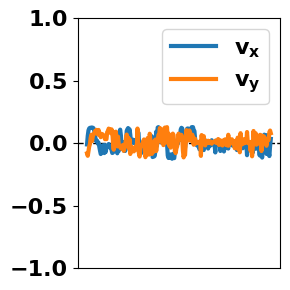

In [27]:
# Rolling-window rollout: generate a long horizon while keeping model context bounded.
T_init           = 1       # frames of real history to seed with
total_pred_steps = 256      # total frames to roll out
chunk_size       = 4       # k: frames generated per sampler call
max_context      = 2      # cap on frames fed to the model

init_latents = latents[:, :T_init, ...].clone()
init_actions = actions[:T_init][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    roll_obs, roll_act = rolling_window_policy_sampler(
        denoiser,
        init_latents       = init_latents,
        init_actions       = init_actions,
        total_pred_steps   = total_pred_steps,
        chunk_size         = chunk_size,
        max_context        = max_context,
        num_diffusion_steps= num_diffusion_steps,
        context_cond_tau = 0.9,
    )
    with torch.no_grad():
        roll_imgs = tokenizer.decode(roll_obs)

plotVideo(roll_imgs[0].to(torch.float32))
plotSnapshots(roll_imgs[0].to(torch.float32), n_frames=8)
plotActions(roll_act[0].cpu().float().numpy())

In [28]:
@torch.no_grad()
def progressive_rolling_sampler(
    denoiser,
    init_latents,           # (B, T_init, N_lat, D_lat) — clean obs context
    init_actions,           # (B, T_init, n_act)        — clean action context
    total_pred_steps,       # frames to emit
    window_size=8,          # F: rolling window size = #steps to fully clean one frame
    context_size=8,         # C: clean prefix kept in front of the window (0 = pure paper algo)
    context_cond_tau=0.9,
    action_noise_std=1.0,
):
    """Progressive autoregressive rolling sampler.

    Adapts 'Progressive Autoregressive Video Diffusion Models' (Xie et al., 2024,
    https://arxiv.org/abs/2410.08151) to the UWM joint obs+action flowmatching
    denoiser. Each main-loop iteration:
        1. All F window frames are denoised by one quantum (dt = 1/F).
        2. The frontmost frame reaches tau=1 (clean) and is emitted.
        3. The window shifts left; a fresh pure-noise frame is appended at the back.
        4. The clean prefix (length C) gains the emitted frame and drops its oldest.

    A short F-1 step warmup grows the window from 1 to F so the staircase noise
    schedule is built in place rather than faked from samples.

    Note: this codebase uses tau=1 == clean, tau=0 == pure noise (opposite of the
    paper). The staircase is expressed in this convention throughout.
    """
    F, C = window_size, context_size
    device = init_latents.device
    dtype  = init_latents.dtype
    B, T_init, N_lat, D_lat = init_latents.shape
    n_act = init_actions.shape[-1]
    init_actions = init_actions.to(device=device, dtype=dtype)

    assert C <= T_init, f"context_size C={C} cannot exceed init context T_init={T_init}"
    N = denoiser.cfg.denoiser.num_noise_levels
    assert N % F == 0, "num_noise_levels must be divisible by window_size for an exact stride"

    stride       = N // F          # quanta advanced per Euler step
    step_size    = 1.0 / F         # Euler dt
    tau_cond_idx = get_noise_index(context_cond_tau, N)

    # always-clean prefix (re-noised to tau_cond on every forward)
    prefix_obs = init_latents[:, -C:].clone() if C > 0 else None
    prefix_act = init_actions[:, -C:].clone() if C > 0 else None

    # rolling window starts with a single pure-noise frame; warmup grows it to F.
    z_obs   = torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype)
    z_act   = action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype)
    tau_idx = torch.zeros((B, 1), dtype=torch.long, device=device)

    def _fresh_noise():
        return (
            torch.randn(B, 1, N_lat, D_lat, device=device, dtype=dtype),
            action_noise_std * torch.randn(B, 1, n_act, device=device, dtype=dtype),
            torch.zeros((B, 1), dtype=torch.long, device=device),
        )

    pred_obs_buf, pred_act_buf = [], []

    while len(pred_obs_buf) < total_pred_steps:
        cur_F = z_obs.shape[1]

        # ---- assemble input: noised clean prefix + window ----
        if C > 0:
            p_obs_in = (1.0 - context_cond_tau) * torch.randn_like(prefix_obs) + context_cond_tau * prefix_obs
            p_act_in = ((1.0 - context_cond_tau) * action_noise_std * torch.randn_like(prefix_act)
                        + context_cond_tau * prefix_act)
            obs_in = torch.cat([p_obs_in, z_obs], dim=1)
            act_in = torch.cat([p_act_in, z_act], dim=1)
            prefix_sigma = torch.full((B, C), tau_cond_idx, dtype=torch.long, device=device)
            sigma_idx = torch.cat([prefix_sigma, tau_idx], dim=1)
        else:
            obs_in, act_in, sigma_idx = z_obs, z_act, tau_idx

        step_idx_tensor = torch.zeros((B, C + cur_F), dtype=torch.long, device=device)

        z_hat, act_hat, _ = denoiser(
            noisy_act    = act_in,
            noisy_obs    = obs_in,
            obs_sigma_idx= sigma_idx,
            obs_step_idx = step_idx_tensor,
            act_sigma_idx= sigma_idx,
            act_step_idx = step_idx_tensor,
        )
        act_hat = act_hat.squeeze(-2)
        z_hat_w, act_hat_w = z_hat[:, C:], act_hat[:, C:]

        # ---- per-frame Euler step on the window ----
        tau_cont = tau_idx.float() / float(N)              # (B, cur_F)
        denom    = (1.0 - tau_cont).clamp_min(1e-5)         # (B, cur_F)
        z_obs = z_obs + (z_hat_w   - z_obs) / denom[..., None, None] * step_size
        z_act = z_act + (act_hat_w - z_act) / denom[..., None]       * step_size
        tau_idx = tau_idx + stride

        if cur_F < F:
            # warmup: append a fresh noise frame at the back, no emission
            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs,   new_o], dim=1)
            z_act   = torch.cat([z_act,   new_a], dim=1)
            tau_idx = torch.cat([tau_idx, new_t], dim=1)
        else:
            # main: emit front, shift left, append fresh noise at back
            emit_obs, emit_act = z_obs[:, :1], z_act[:, :1]
            pred_obs_buf.append(emit_obs)
            pred_act_buf.append(emit_act)

            new_o, new_a, new_t = _fresh_noise()
            z_obs   = torch.cat([z_obs[:, 1:],   new_o], dim=1)
            z_act   = torch.cat([z_act[:, 1:],   new_a], dim=1)
            tau_idx = torch.cat([tau_idx[:, 1:], new_t], dim=1)

            if C > 0:
                prefix_obs = torch.cat([prefix_obs[:, 1:], emit_obs], dim=1)
                prefix_act = torch.cat([prefix_act[:, 1:], emit_act], dim=1)

    return torch.cat(pred_obs_buf, dim=1), torch.cat(pred_act_buf, dim=1)

This browser does not support the video tag.


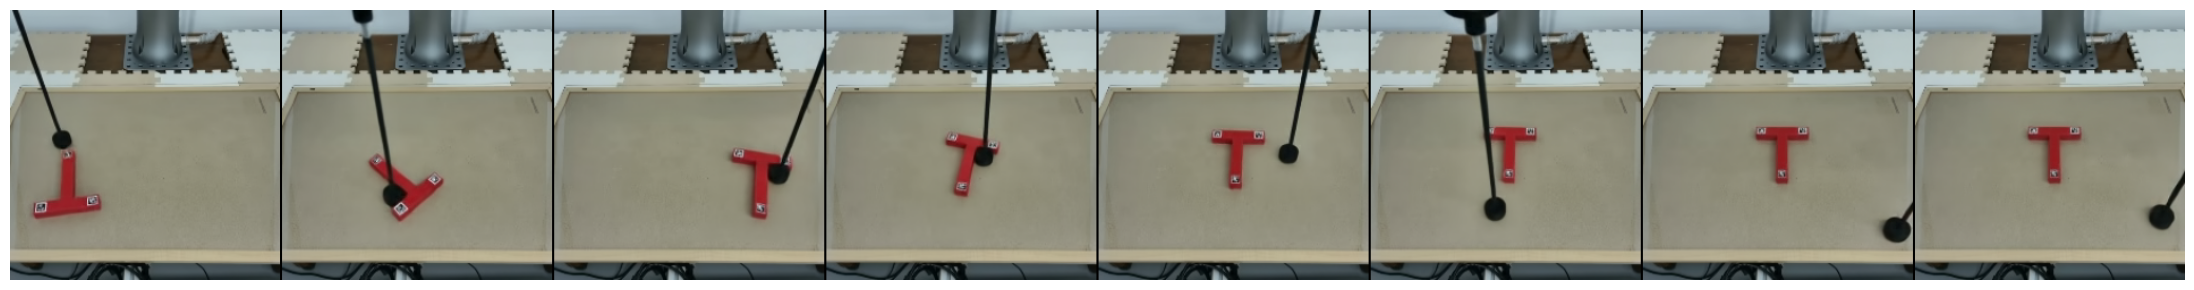

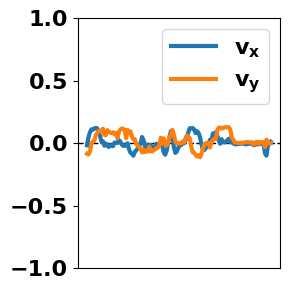

In [29]:
# Progressive autoregressive rollout: per-frame staircase noise schedule.
total_pred_steps = 128      # frames to emit
window_size      = 4       # F: per-frame staircase depth (= #steps to clean one frame)
context_size     = 8       # C: clean overlap-conditioning prefix

# init_latents = latents[:, :T_init, ...].clone()
# init_actions = actions[:T_init][None].cuda()

init_latents = latents[:, 0, ...].clone().unsqueeze(1).repeat(1, context_size, 1, 1)
init_actions = torch.zeros_like(actions[:context_size][None].cuda())


with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    prog_obs, prog_act = progressive_rolling_sampler(
        denoiser,
        init_latents     = init_latents,
        init_actions     = init_actions,
        total_pred_steps = total_pred_steps,
        window_size      = window_size,
        context_size     = context_size,
    )
    with torch.no_grad():
        prog_imgs = tokenizer.decode(prog_obs)

plotVideo(prog_imgs[0].to(torch.float32))
plotSnapshots(prog_imgs[0].to(torch.float32), n_frames=8)
plotActions(prog_act[0].cpu().float().numpy())

# Autoregressive Sampling — `AutoRegressiveForwardDynamics`

KV-cached, frame-by-frame rollout for the **flow-matching** UWM denoiser. The class wraps the denoiser and tokenizer together with their decoder caches and supports two modes:

- **`wm`** — world model. The caller passes the next action at every `step()`; the action is treated as clean and only the next observation is denoised.
- **`policy`** — `step()` takes no input; the next observation and the next action are denoised jointly. Context actions are slightly noised at `tau_cond` to match policy training.

Both modes prime the cache via `reset(imgs_init, actions_init)` and then advance one frame per `step()`.


In [30]:
from dreamerv4uwm.sampling import AutoRegressiveForwardDynamics
episode_length = 128
demo_end_index = 3
num_pred_steps = episode_length - demo_end_index
T_ctx = demo_end_index

denoising_step_count = 8        # power of two; flow-matching Euler steps per frame
context_cond_tau = 0.99
# max_forward_steps = T_ctx + num_pred_steps + 4   # safety margin for KV cache size
max_forward_steps = 32   # safety margin for KV cache size

imgs_ctx = imgs[:, :T_ctx]                      # (1, T_ctx, C, H, W)
actions_ctx = actions[:T_ctx][None].to(device)  # (1, T_ctx, n_act)

N_batch = 1
imgs_ctx = imgs_ctx.expand(N_batch, -1, -1, -1, -1)
actions_ctx = actions_ctx.expand(N_batch, -1, -1)

## 1. World-model rollout (`mode='wm'`)
We supply the next action at every step — actions are treated as clean and only the next obs is denoised. We feed the ground-truth future actions for the visualisation.


In [31]:
ar_wm = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='wm',
    context_length=32,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)

future_actions_wm = actions.clone()[None, T_ctx:T_ctx + num_pred_steps, :].to(device)  # (1, num_pred_steps, n_act)

frames_wm = []
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ar_wm.reset(imgs_ctx, actions_ctx)
    for t in range(num_pred_steps):
        img_t = ar_wm.step(actions_t=future_actions_wm[:, t])
        frames_wm.append(img_t.detach().cpu())

video_wm = torch.stack(frames_wm, dim=1)[0]      # (num_pred_steps, C, H, W)
plotVideo(video_wm.to(torch.float32))
plotSnapshots(video_wm.to(torch.float32), n_frames=5)

IndexError: index 93 is out of bounds for dimension 1 with size 93

## 2. Policy rollout (`mode='policy'`)
No actions are fed during rollout — the policy denoises the next obs and the next action jointly at each step.


In [ ]:
ar_pol = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='policy',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)



In [ ]:
frames_pol, acts_pol = [], []
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        ar_pol.reset(imgs_ctx, actions_ctx)
        for t in range(num_pred_steps):
            img_t, act_t = ar_pol.step()
            frames_pol.append(img_t.detach().cpu())
            acts_pol.append(act_t.detach().cpu())

In [ ]:
video_pol = torch.stack(frames_pol, dim=1)
acts_pol_seq = torch.stack(acts_pol, dim=1)

video_all = torch.concat([imgs[:, :T_ctx].cpu().expand(video_pol.shape[0], -1, -1, -1, -1), video_pol.cpu()], dim=1)  # (1, 3, T, C, H, W)
# actions_all = torch.concat([actions[:T_ctx].cpu(), acts_pol_seq.cpu()], dim=0)  # (1, T, n_act)
for k in range(video_all.shape[0]):
    plotVideo(video_all.to(torch.float32)[k])

# plotSnapshots(video_all.to(torch.float32), n_frames=5)
# plotActions(acts_pol_seq.to(torch.float32))

This browser does not support the video tag.


# RAP-mode diversity test

**Hypothesis:** the noisy-context inference mode (a.k.a. RAP — random action
proposer) generates more diverse joint state+action rollouts than the
clean-context policy mode at the same compute. If true, RAP is a natural
source of multi-modal action proposals for tree-expansion / planning — a
capability MAC (Park et al., OGBench SOTA) achieves via *rejection sampling*
on a flow policy.

**Test design:** from a fixed context, draw K rollouts at each of several
`context_cond_tau` levels (1.0 = clean → 0.0 = pure noise; the existing
`unified_flowmatching_sampler` exposes this directly via `context_cond_tau`).
Measure:

- **Action diversity**: per-frame std across the K samples (mean over time);
  mean pairwise L2 distance between sample trajectories.
- **State (latent) diversity**: per-frame std of the predicted latents across
  the K samples.

**Decision rule:** if action_std and latent_std curves are monotonically
increasing as `context_cond_tau` decreases (more noisy context → more
diverse output), RAP works as intended and we can claim native multi-modal
sampling without rejection. If diversity is flat or non-monotonic, the
property collapses and we have to drop the claim.

In [32]:
import numpy as np
import torch

# `progressive_rolling_sampler` is defined as a function earlier in this
# notebook (cell ~13). It emits horizon frames left-to-right with a staircase
# noise schedule, so each newly emitted frame is conditioned on all prior
# (already-clean) emissions. This is more honest for measuring multi-plan
# diversity than the parallel sampler — joint-parallel denoising can produce
# K samples whose differences are largely temporal incoherence rather than
# coherent alternative trajectories.


@torch.no_grad()
def sample_K_rollouts(K, ctx_lat_1, ctx_act_1, num_pred_steps,
                      window_size, context_cond_tau,
                      action_noise_std=1.0):
    """Draw K i.i.d. (z, a) rollouts from a single (ctx_lat, ctx_act) seed via
    the progressive rolling sampler.

    Replicates the context across the batch dim so K rollouts share the same
    seed but receive independent ε / fresh-noise draws inside the sampler.

    Returns:
        pred_obs (K, num_pred_steps, N_lat, D_lat),
        pred_act (K, num_pred_steps, n_act)
    """
    ctx_lat = ctx_lat_1.expand(K, -1, -1, -1).contiguous()
    ctx_act = ctx_act_1.expand(K, -1, -1).contiguous()
    context_size = ctx_lat.shape[1]
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        pred_obs, pred_act = progressive_rolling_sampler(
            denoiser,
            init_latents=ctx_lat,
            init_actions=ctx_act,
            total_pred_steps=num_pred_steps,
            window_size=window_size,          # F: per-frame staircase depth
            context_size=context_size,        # C: clean-prefix size = full ctx
            context_cond_tau=context_cond_tau,
            action_noise_std=action_noise_std,
        )
    return pred_obs, pred_act


def diversity_stats(samples_K):
    """(K, T, *) -> dict of per-frame std (T,) and mean pairwise L2 scalar."""
    x = samples_K.float()
    K = x.shape[0]
    flat = x.reshape(K, x.shape[1], -1)
    per_t_std = flat.std(dim=0).mean(dim=-1).cpu().numpy()
    pdists = []
    for i in range(K):
        for j in range(i + 1, K):
            d = (flat[i] - flat[j]).pow(2).sum(dim=-1).sqrt().mean()
            pdists.append(d.item())
    return {'per_t_std': per_t_std, 'pairwise_dist_mean': float(np.mean(pdists))}

In [42]:
# --- RAP diversity sweep (progressive rolling sampler) ---
T_ctx_rap          = 1       # short context — gives the model room to imagine
num_pred_steps_rap = 32
window_size_rap    = 8       # F: per-frame staircase depth (denoising quanta per frame)
K                  = 8       # rollouts per tau level
TAUS = [0.99, 0.7, 0.5, 0.3, 0.2, 0.1, 0.05]

# Reuse the loaded `latents` and `actions` from the early cells.
ctx_lat_1 = latents[:, :T_ctx_rap].clone()
ctx_act_1 = actions[:T_ctx_rap][None].to(device)

results = {}
torch.manual_seed(0)
for tau in TAUS:
    pred_obs, pred_act = sample_K_rollouts(
        K=K, ctx_lat_1=ctx_lat_1, ctx_act_1=ctx_act_1,
        num_pred_steps=num_pred_steps_rap,
        window_size=window_size_rap,
        context_cond_tau=tau,
    )
    act_stats = diversity_stats(pred_act)
    obs_stats = diversity_stats(pred_obs)
    results[tau] = {
        'pred_obs': pred_obs, 'pred_act': pred_act,
        'act_per_t_std': act_stats['per_t_std'],
        'act_pairwise':  act_stats['pairwise_dist_mean'],
        'obs_per_t_std': obs_stats['per_t_std'],
        'obs_pairwise':  obs_stats['pairwise_dist_mean'],
    }
    print(f"ctx_cond_tau={tau:>4.2f}  "
          f"action[mean_std={act_stats['per_t_std'].mean():.4f} "
          f"pairwise_L2={act_stats['pairwise_dist_mean']:.4f}]  "
          f"obs[mean_std={obs_stats['per_t_std'].mean():.4f} "
          f"pairwise_L2={obs_stats['pairwise_dist_mean']:.4f}]")

ctx_cond_tau=0.99  action[mean_std=0.0411 pairwise_L2=0.0705]  obs[mean_std=0.0891 pairwise_L2=19.2022]
ctx_cond_tau=0.70  action[mean_std=0.0452 pairwise_L2=0.0787]  obs[mean_std=0.0915 pairwise_L2=19.6937]
ctx_cond_tau=0.50  action[mean_std=0.0452 pairwise_L2=0.0813]  obs[mean_std=0.1139 pairwise_L2=22.5169]
ctx_cond_tau=0.30  action[mean_std=0.0491 pairwise_L2=0.0874]  obs[mean_std=0.1219 pairwise_L2=22.5629]
ctx_cond_tau=0.20  action[mean_std=0.0476 pairwise_L2=0.0870]  obs[mean_std=0.1211 pairwise_L2=22.9139]
ctx_cond_tau=0.10  action[mean_std=0.0435 pairwise_L2=0.0793]  obs[mean_std=0.1364 pairwise_L2=24.1133]
ctx_cond_tau=0.05  action[mean_std=0.0469 pairwise_L2=0.0853]  obs[mean_std=0.1375 pairwise_L2=24.1072]


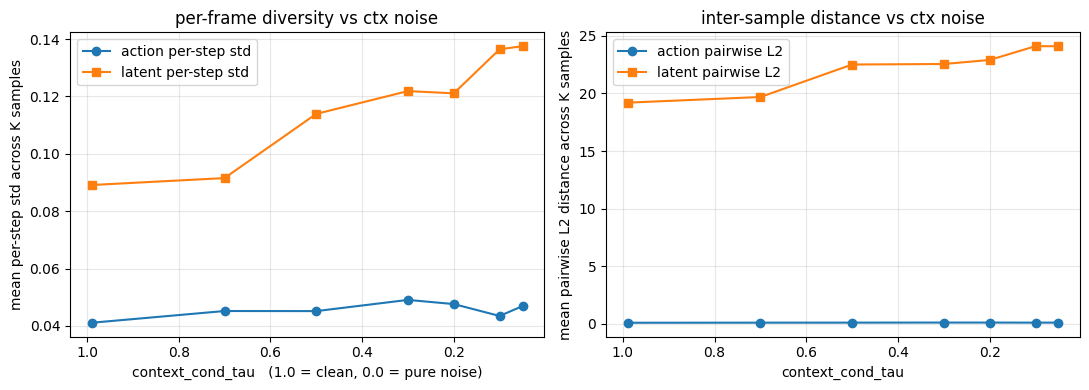

In [43]:
# --- Diversity vs tau plot ---
import matplotlib.pyplot as plt

taus = sorted(results.keys(), reverse=True)  # clean → noisy on x axis
act_mean_std = [results[t]['act_per_t_std'].mean() for t in taus]
act_pair     = [results[t]['act_pairwise']         for t in taus]
obs_mean_std = [results[t]['obs_per_t_std'].mean() for t in taus]
obs_pair     = [results[t]['obs_pairwise']         for t in taus]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(taus, act_mean_std, 'o-', label='action per-step std', color='C0')
axes[0].plot(taus, obs_mean_std, 's-', label='latent per-step std', color='C1')
axes[0].set_xlabel('context_cond_tau   (1.0 = clean, 0.0 = pure noise)')
axes[0].set_ylabel('mean per-step std across K samples')
axes[0].set_title('per-frame diversity vs ctx noise')
axes[0].invert_xaxis()
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(taus, act_pair, 'o-', label='action pairwise L2', color='C0')
axes[1].plot(taus, obs_pair, 's-', label='latent pairwise L2', color='C1')
axes[1].set_xlabel('context_cond_tau')
axes[1].set_ylabel('mean pairwise L2 distance across K samples')
axes[1].set_title('inter-sample distance vs ctx noise')
axes[1].invert_xaxis()
axes[1].grid(alpha=0.3); axes[1].legend()

fig.tight_layout()
plt.show()

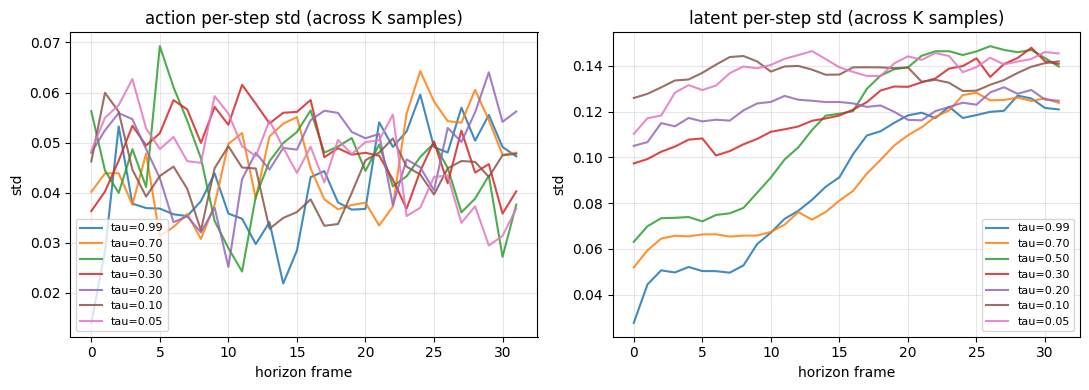

In [44]:
# --- Per-frame std curves (look for late-horizon divergence) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for tau in taus:
    axes[0].plot(results[tau]['act_per_t_std'], label=f'tau={tau:.2f}', alpha=0.85)
    axes[1].plot(results[tau]['obs_per_t_std'], label=f'tau={tau:.2f}', alpha=0.85)
axes[0].set_title('action per-step std (across K samples)')
axes[0].set_xlabel('horizon frame'); axes[0].set_ylabel('std')
axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title('latent per-step std (across K samples)')
axes[1].set_xlabel('horizon frame'); axes[1].set_ylabel('std')
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [47]:
# --- Visualize K rollouts at clean ctx vs noisy ctx side-by-side ---
import mediapy

def show_K_rollouts(pred_obs, K, label, fps=10):
    """Decode K rollouts and display as a side-by-side video grid."""
    with torch.no_grad():
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            imgs_K = tokenizer.decode(pred_obs)
    imgs_K = imgs_K.clamp(0, 1).cpu().float()
    grid = {}
    for k in range(K):
        v = (imgs_K[k].permute(0, 2, 3, 1).numpy() * 255).astype(np.uint8)
        grid[f'#{k}'] = v
    print(label)
    mediapy.show_videos(grid, fps=fps, columns=min(K, 4))

show_K_rollouts(results[0.99]['pred_obs'], K=K, label='ctx_cond_tau=0.99 (policy / clean ctx)')
show_K_rollouts(results[0.5]['pred_obs'],  K=K, label='ctx_cond_tau=0.30 (RAP / noisy ctx)')

ctx_cond_tau=0.99 (policy / clean ctx)


#0 This browser does not support the video tag.,#1 This browser does not support the video tag.,#2 This browser does not support the video tag.,#3 This browser does not support the video tag.
#4 This browser does not support the video tag.,#5 This browser does not support the video tag.,#6 This browser does not support the video tag.,#7 This browser does not support the video tag.


ctx_cond_tau=0.30 (RAP / noisy ctx)


#0 This browser does not support the video tag.,#1 This browser does not support the video tag.,#2 This browser does not support the video tag.,#3 This browser does not support the video tag.
#4 This browser does not support the video tag.,#5 This browser does not support the video tag.,#6 This browser does not support the video tag.,#7 This browser does not support the video tag.


## What to look for

- **Monotonicity of the diversity curves.** As `context_cond_tau` drops from
  ~1.0 (clean / policy) to ~0.0 (pure noise / strong RAP), do the action and
  latent std/pairwise-distance curves rise monotonically? If yes, RAP
  produces more diverse rollouts than clean-context policy at the same
  compute → claim holds.

- **Per-frame curves.** Does diversity grow with horizon frame? Expected:
  early-horizon frames look similar across samples (model still committed to
  its context interpretation); late-horizon frames diverge more. The
  inter-tau gap should also widen at late horizon if RAP is the dominant
  diversity source.

- **Visual sanity.** In the K-rollouts video grids, the clean-ctx samples
  should look qualitatively similar to each other (all attempting the same
  task in roughly the same way), while the noisy-ctx samples should show
  qualitatively different trajectories — different motion plans, different
  task strategies. If clean and noisy look the same, the diversity stats
  alone aren't enough — the model is producing near-identical rollouts with
  only nuisance variation, and RAP isn't doing what we claim.

- **Failure mode to watch for.** Very low `context_cond_tau` (e.g., 0.05)
  may push the context off the model's training manifold → outputs become
  noise rather than diverse rollouts. The diversity number rises but
  visually it's garbage. Use the video grid to distinguish "diverse and
  valid" from "noisy and broken."